# EDA - SemEval2026 Task 13A

Exploratory Data Analysis for Machine-Generated Code Detection.

**Contents:**
1. Data overview & basic stats
2. Label distribution
3. Language distribution
4. Generator distribution
5. Code length & line count
6. Comment density & whitespace analysis
7. Cross-analysis (language x label, length x label)
8. Sample code inspection

In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

%matplotlib inline

## 1. Load Data

Raw data contains **train**, **validation**, and **test** splits.

In [9]:
train_df = pd.read_parquet('../data/raw/train.parquet')
val_df = pd.read_parquet('../data/raw/validation.parquet')
test_df = pd.read_parquet('../data/raw/test.parquet')

print(f'Train: {train_df.shape[0]:>8,} rows x {train_df.shape[1]} cols  {train_df.columns.tolist()}')
print(f'Val:   {val_df.shape[0]:>8,} rows x {val_df.shape[1]} cols  {val_df.columns.tolist()}')
print(f'Test:  {test_df.shape[0]:>8,} rows x {test_df.shape[1]} cols  {test_df.columns.tolist()}')

Train:  500,000 rows x 4 cols  ['code', 'generator', 'label', 'language']
Val:    100,000 rows x 4 cols  ['code', 'generator', 'label', 'language']
Test:   500,000 rows x 2 cols  ['ID', 'code']


In [10]:
train_df.head(3)

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


In [11]:
train_df.info()
print()
train_df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   code       500000 non-null  str  
 1   generator  500000 non-null  str  
 2   label      500000 non-null  int64
 3   language   500000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 426.9 MB



,code,generator,label,language
count,500000,500000,500000.000000,500000
unique,500000,35,NaN,3
top,"(a, b, c, d) = [int(x) for x in input().split(...",human,NaN,Python
freq,1,238475,NaN,457306
mean,NaN,NaN,0.523050,NaN
std,NaN,NaN,0.499469,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,1.000000,NaN
75%,NaN,NaN,1.000000,NaN


### Validation set overview

In [12]:
val_df.info()
print()
val_df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   code       100000 non-null  str  
 1   generator  100000 non-null  str  
 2   label      100000 non-null  int64
 3   language   100000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 85.2 MB



,code,generator,label,language
count,100000,100000,100000.000000,100000
unique,100000,35,NaN,3
top,import sys\ninf = float('inf')\nfrom bisect im...,human,NaN,Python
freq,1,47695,NaN,91461
mean,NaN,NaN,0.523050,NaN
std,NaN,NaN,0.499471,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,1.000000,NaN
75%,NaN,NaN,1.000000,NaN


In [13]:
val_df.head(3)

,code,generator,label,language
0,import sys\ninf = float('inf')\nfrom bisect im...,human,0,Python
1,"def Range(a): return min(max(a, -10), 10)\n\nd...",meta-llama/Llama-3.1-8B,1,Python
2,#include<bits/stdc++.h>\n\n\n\nusing namespace...,human,0,C++


In [14]:
label_names = {0: 'Human', 1: 'AI-Generated'}

# Validation label distribution
print('=== Validation Label Distribution ===')
val_label_counts = val_df['label'].value_counts().sort_index()
for idx_val, cnt in val_label_counts.items():
    print(f'  {label_names.get(idx_val, idx_val)}: {cnt:>8,} ({cnt/len(val_df)*100:.1f}%)')
print(f'  AI ratio: {val_df["label"].mean():.3f}')
print()

# Validation language distribution
print('=== Validation Language Distribution ===')
val_lang_counts = val_df['language'].value_counts()
for lang, cnt in val_lang_counts.items():
    print(f'  {lang}: {cnt:>8,} ({cnt/len(val_df)*100:.1f}%)')
print()

# Validation generator diversity
print(f'Unique generators in val: {val_df["generator"].nunique()}')
print(f'Generators in val but NOT in train: {set(val_df["generator"].unique()) - set(train_df["generator"].unique())}')
print(f'Generators in train but NOT in val: {set(train_df["generator"].unique()) - set(val_df["generator"].unique())}')

=== Validation Label Distribution ===
  Human:   47,695 (47.7%)
  AI-Generated:   52,305 (52.3%)
  AI ratio: 0.523

=== Validation Language Distribution ===
  Python:   91,461 (91.5%)
  C++:    4,679 (4.7%)
  Java:    3,860 (3.9%)

Unique generators in val: 35
Generators in val but NOT in train: set()
Generators in train but NOT in val: set()


## 2. Label Distribution

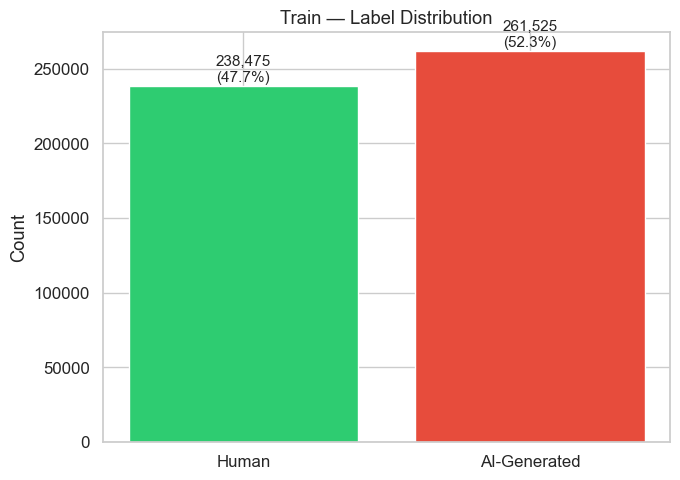

Train label ratio (AI/Human): 0.523


In [15]:
label_names = {0: 'Human', 1: 'AI-Generated'}

fig, ax = plt.subplots(figsize=(7, 5))

counts = train_df['label'].value_counts().sort_index()
bars = ax.bar([label_names[i] for i in counts.index], counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Train — Label Distribution')
ax.set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
            f'{count:,}\n({count/len(train_df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Train label ratio (AI/Human): {train_df["label"].mean():.3f}')

## 3. Language Distribution

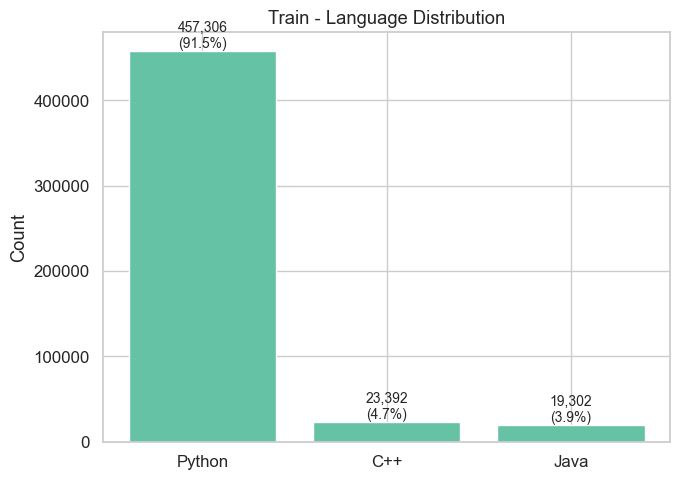

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

lang_counts = train_df['language'].value_counts()
bars = ax.bar(lang_counts.index, lang_counts.values)
ax.set_title('Train - Language Distribution')
ax.set_ylabel('Count')
for bar, count in zip(bars, lang_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({count/len(train_df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
# Language x Label crosstab
ct = pd.crosstab(train_df['language'], train_df['label'].map(label_names), margins=True)
ct_pct = pd.crosstab(train_df['language'], train_df['label'].map(label_names), normalize='index') * 100

print('=== Counts ===')
display(ct)
print()
print('=== Row % ===')
display(ct_pct.round(1))

=== Counts ===


label,AI-Generated,Human,All
language,,,
C++,12245,11147,23392
Java,10077,9225,19302
Python,239203,218103,457306
All,261525,238475,500000



=== Row % ===


label,AI-Generated,Human
language,,
C++,52.3,47.7
Java,52.2,47.8
Python,52.3,47.7


## 4. Generator Distribution

Total unique generators: 35
Human samples: 238,475
AI generators: 34



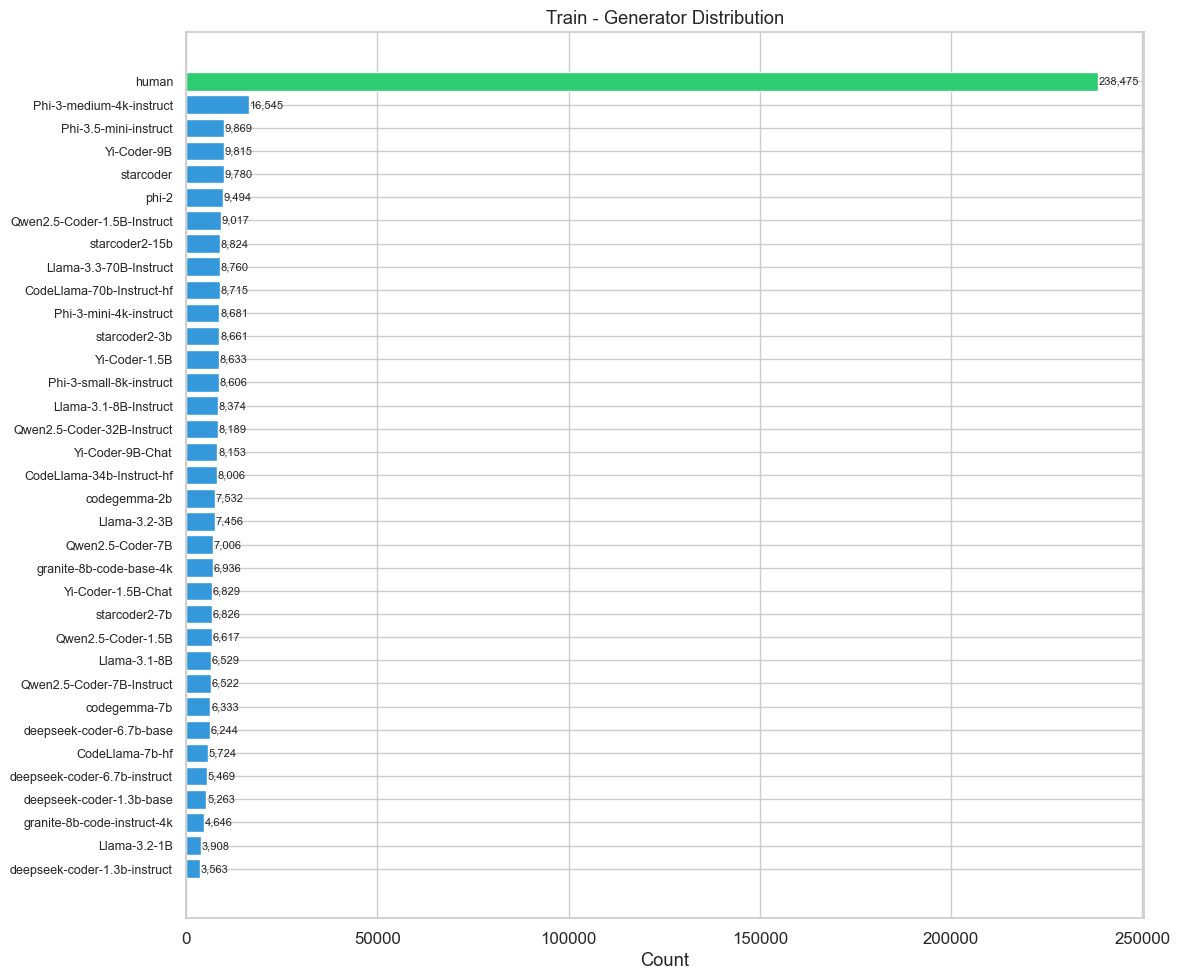

In [18]:
gen_counts = train_df['generator'].value_counts()
print(f'Total unique generators: {len(gen_counts)}')
print(f'Human samples: {gen_counts["human"]:,}')
print(f'AI generators: {len(gen_counts) - 1}')
print()

fig, ax = plt.subplots(figsize=(12, 10))
gen_counts_sorted = gen_counts.sort_values()
colors = ['#2ecc71' if g == 'human' else '#3498db' for g in gen_counts_sorted.index]
ax.barh(range(len(gen_counts_sorted)), gen_counts_sorted.values, color=colors)
ax.set_yticks(range(len(gen_counts_sorted)))
ax.set_yticklabels([g.split('/')[-1] if '/' in g else g for g in gen_counts_sorted.index], fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Train - Generator Distribution')

for i, count in enumerate(gen_counts_sorted.values):
    ax.text(count + 200, i, f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# Generator x Language
gen_lang = pd.crosstab(train_df['generator'], train_df['language'])
print('Top 10 generators by language:')
display(gen_lang.loc[gen_counts.head(10).index])

Top 10 generators by language:


language,C++,Java,Python
generator,,,
human,11147,9225,218103
microsoft/Phi-3-medium-4k-instruct,719,646,15180
microsoft/Phi-3.5-mini-instruct,461,403,9005
01-ai/Yi-Coder-9B,400,366,9049
bigcode/starcoder,426,367,8987
microsoft/phi-2,389,345,8760
Qwen/Qwen2.5-Coder-1.5B-Instruct,440,356,8221
bigcode/starcoder2-15b,381,321,8122
meta-llama/Llama-3.3-70B-Instruct,443,340,7977


## 5. Code Length & Line Count

In [20]:
# Compute length features
for df in [train_df, test_df]:
    df['code_length'] = df['code'].str.len()
    df['num_lines'] = df['code'].str.count('\n') + 1

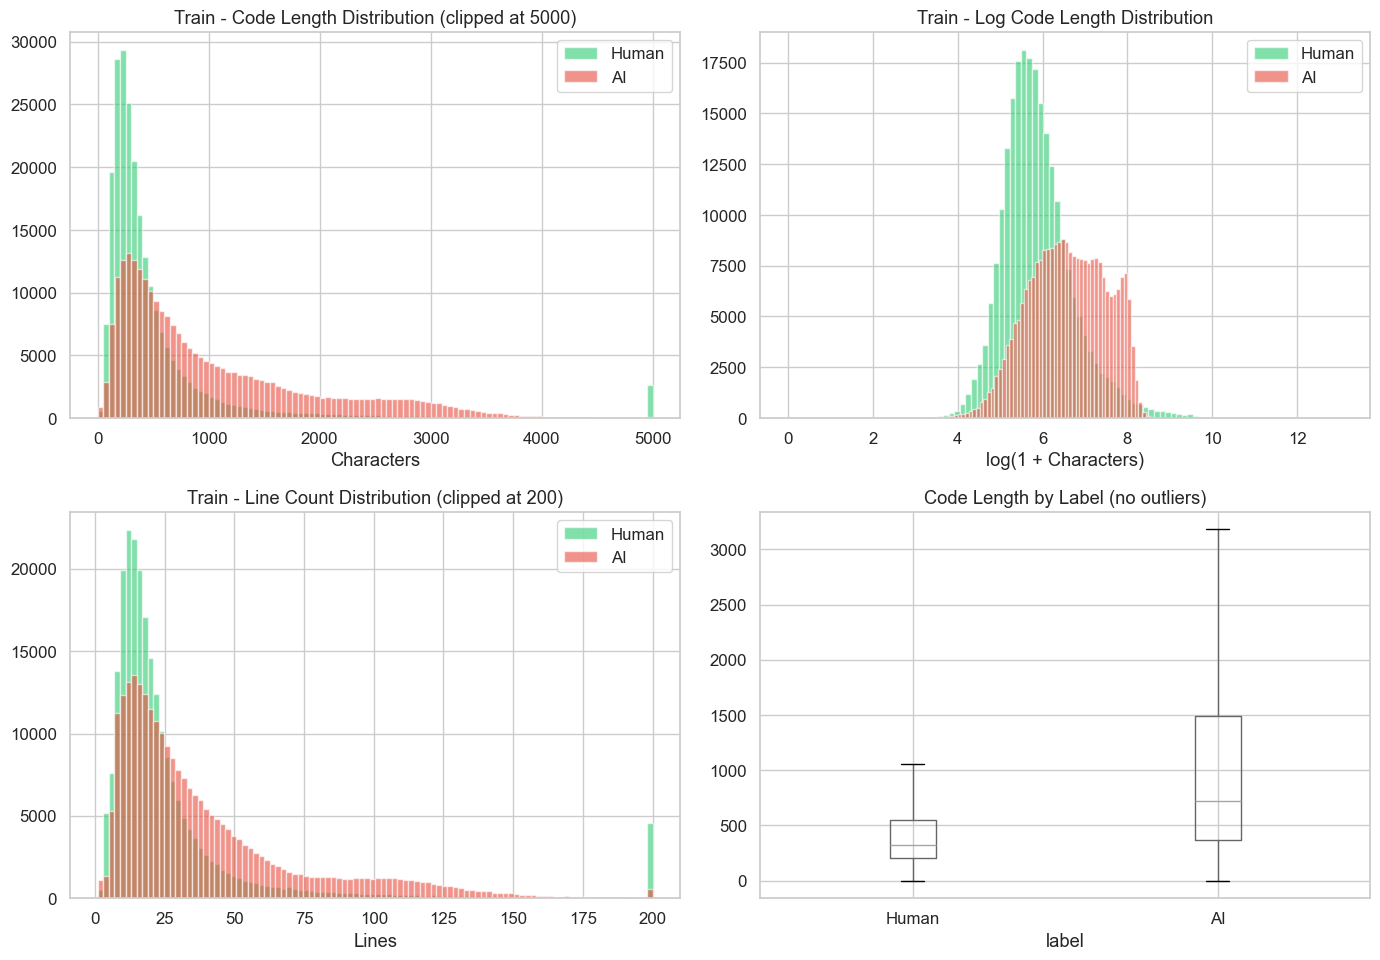

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Code length distribution
for label_val, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
    subset = train_df[train_df['label'] == label_val]['code_length']
    axes[0, 0].hist(subset.clip(upper=5000), bins=100, alpha=0.6, label=name, color=color)
axes[0, 0].set_title('Train - Code Length Distribution (clipped at 5000)')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].legend()

# Log scale
for label_val, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
    subset = train_df[train_df['label'] == label_val]['code_length']
    axes[0, 1].hist(np.log1p(subset), bins=100, alpha=0.6, label=name, color=color)
axes[0, 1].set_title('Train - Log Code Length Distribution')
axes[0, 1].set_xlabel('log(1 + Characters)')
axes[0, 1].legend()

# Line count
for label_val, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
    subset = train_df[train_df['label'] == label_val]['num_lines']
    axes[1, 0].hist(subset.clip(upper=200), bins=100, alpha=0.6, label=name, color=color)
axes[1, 0].set_title('Train - Line Count Distribution (clipped at 200)')
axes[1, 0].set_xlabel('Lines')
axes[1, 0].legend()

# Box plot by label
train_df.boxplot(column='code_length', by='label', ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title('Code Length by Label (no outliers)')
axes[1, 1].set_xticklabels(['Human', 'AI'])
plt.suptitle('')

plt.tight_layout()
plt.show()

In [22]:
# Length stats by label
print('=== Code Length Stats ===')
display(train_df.groupby('label')['code_length'].describe().round(0))
print()
print('=== Line Count Stats ===')
display(train_df.groupby('label')['num_lines'].describe().round(0))

=== Code Length Stats ===


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,238475.0,600.0,1722.0,0.0,205.0,319.0,546.0,475006.0
1,261525.0,1053.0,894.0,1.0,370.0,726.0,1494.0,11964.0



=== Line Count Stats ===


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,238475.0,33.0,84.0,1.0,12.0,17.0,28.0,3775.0
1,261525.0,40.0,35.0,1.0,16.0,28.0,51.0,298.0


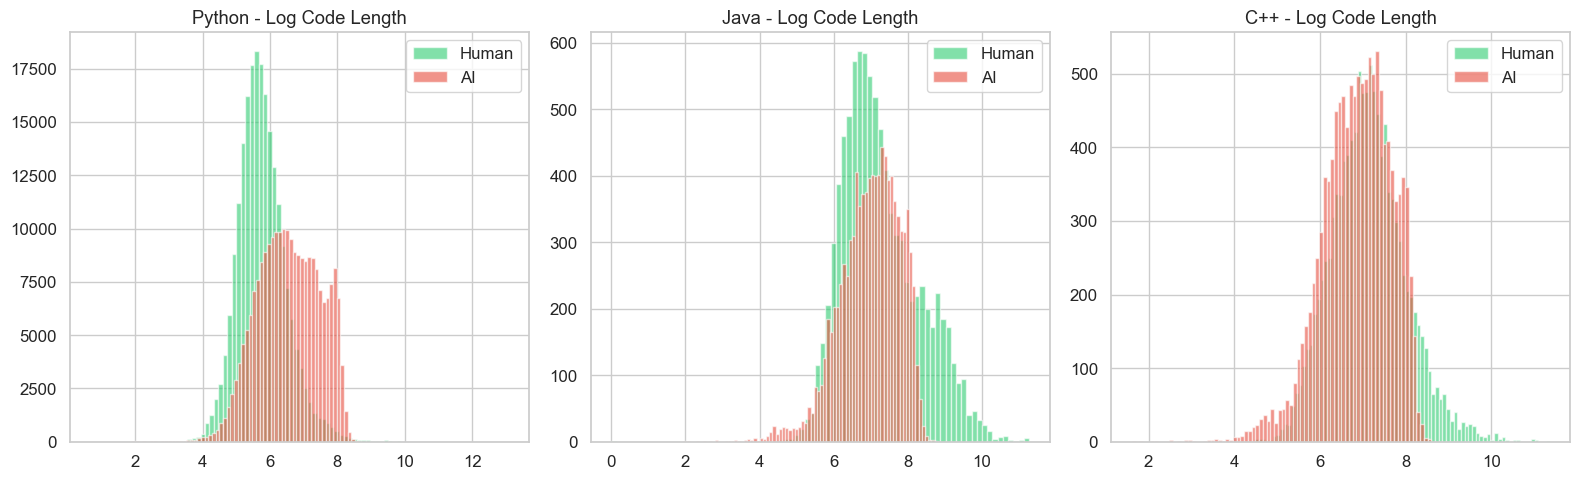

In [23]:
# Length distribution by language
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lang in zip(axes, train_df['language'].unique()):
    subset = train_df[train_df['language'] == lang]
    for label_val, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
        s = subset[subset['label'] == label_val]['code_length']
        ax.hist(np.log1p(s), bins=80, alpha=0.6, label=name, color=color)
    ax.set_title(f'{lang} - Log Code Length')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Comment Density & Whitespace Analysis

In [24]:
def compute_code_features(code: str) -> dict:
    """Compute lightweight features for EDA."""
    lines = code.split('\n')
    non_empty = [l for l in lines if l.strip()]
    comment_lines = len(re.findall(r'^\s*(?://|#|/\*|\*)', code, re.MULTILINE))
    
    return {
        'comment_density': comment_lines / max(len(lines), 1),
        'whitespace_ratio': code.count(' ') / max(len(code), 1),
        'blank_line_ratio': 1 - len(non_empty) / max(len(lines), 1),
        'mean_line_length': np.mean([len(l) for l in lines]) if lines else 0,
        'max_line_length': max([len(l) for l in lines]) if lines else 0,
        'mean_indent': np.mean([len(l) - len(l.lstrip()) for l in non_empty]) if non_empty else 0,
        'semicolon_count': code.count(';'),
        'brace_count': code.count('{') + code.count('}'),
    }

# Sample for speed (full dataset is 500K)
SAMPLE_SIZE = 500_000
sample_df = train_df.sample(n=SAMPLE_SIZE, random_state=42).copy()

features = sample_df['code'].apply(compute_code_features).apply(pd.Series)
sample_df = pd.concat([sample_df, features], axis=1)

print(f'Computed features on {len(sample_df):,} samples')
sample_df[features.columns].describe().round(3)

Computed features on 500,000 samples


,comment_density,whitespace_ratio,blank_line_ratio,mean_line_length,max_line_length,mean_indent,semicolon_count,brace_count
count,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000
mean,0.037,0.212,0.136,22.866,78.957,3.118,3.712,3.218
std,0.088,0.100,0.116,56.119,719.952,2.969,18.361,14.852
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.136,0.059,16.231,39.000,0.913,0.000,0.000
50%,0.000,0.184,0.108,20.444,55.000,2.000,0.000,0.000
75%,0.026,0.275,0.185,26.130,83.000,4.720,0.000,0.000
max,1.000,0.764,1.000,30323.250,474614.000,52.250,1389.000,1358.000


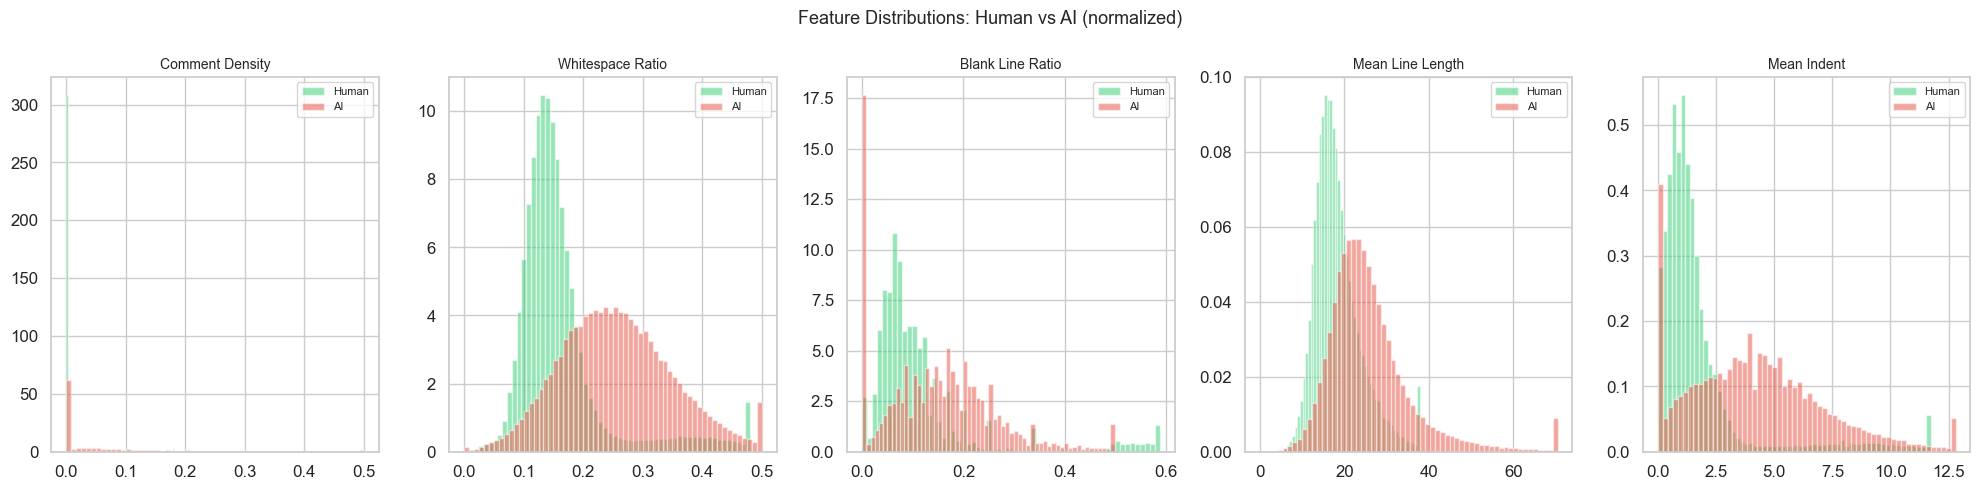

In [25]:
feature_cols = ['comment_density', 'whitespace_ratio', 'blank_line_ratio', 
                'mean_line_length', 'mean_indent']

fig, axes = plt.subplots(1, len(feature_cols), figsize=(20, 5))

for ax, col in zip(axes, feature_cols):
    for label_val, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
        subset = sample_df[sample_df['label'] == label_val][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=60, alpha=0.5, 
                label=name, color=color, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Human vs AI (normalized)', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Feature means by label
print('=== Mean Feature Values by Label ===')
display(sample_df.groupby('label')[feature_cols + ['semicolon_count', 'brace_count']].mean().round(4).T)

=== Mean Feature Values by Label ===


label,0,1
comment_density,0.0060,0.0645
whitespace_ratio,0.1633,0.2561
blank_line_ratio,0.1171,0.1536
mean_line_length,18.8860,26.4957
mean_indent,1.8542,4.2701
semicolon_count,4.0726,3.3825
brace_count,3.2628,3.1779


In [27]:
# Feature means by language x label
print('=== Mean Feature Values by Language x Label ===')
display(sample_df.groupby(['language', 'label'])[feature_cols].mean().round(4))

=== Mean Feature Values by Language x Label ===


comment_density  whitespace_ratio  blank_line_ratio  \
language label                                                        
C++      0               0.0819            0.2834            0.2720   
         1               0.0879            0.2854            0.1230   
Java     0               0.0281            0.3466            0.2509   
         1               0.0525            0.3052            0.1290   
Python   0               0.0012            0.1495            0.1035   
         1               0.0638            0.2525            0.1561   

                mean_line_length  mean_indent  
language label                                 
C++      0               19.1072       5.2913  
         1               25.6842       5.0146  
Java     0               21.7963       8.1231  
         1               29.1476       6.6217  
Python   0               18.7516       1.4134  
         1               26.4255       4.1329

## 7. Correlation Analysis

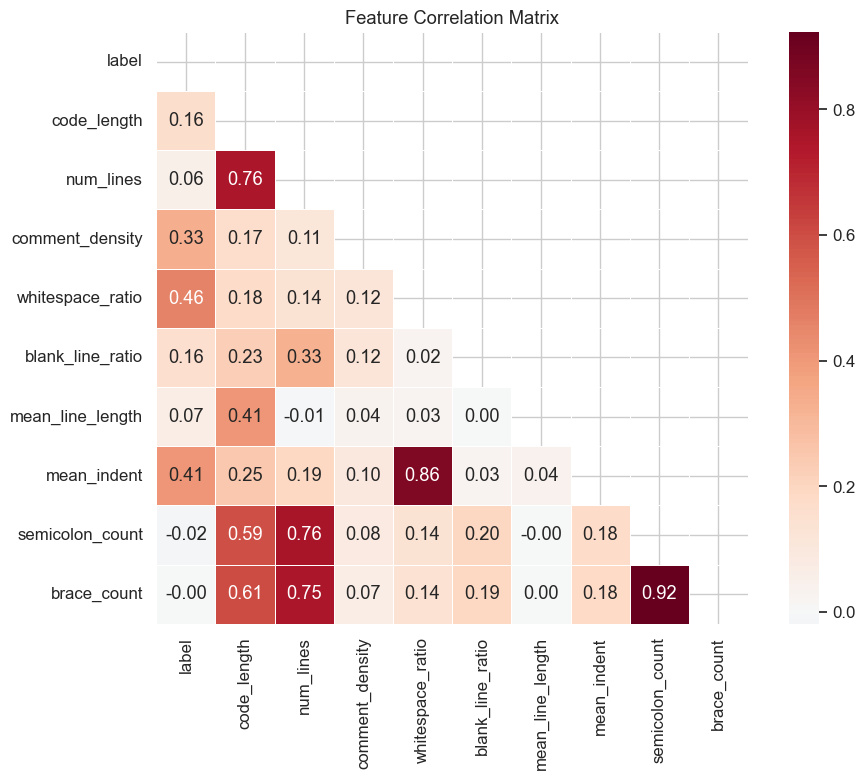

In [28]:
corr_cols = ['label', 'code_length', 'num_lines', 'comment_density', 
             'whitespace_ratio', 'blank_line_ratio', 'mean_line_length', 
             'mean_indent', 'semicolon_count', 'brace_count']

fig, ax = plt.subplots(figsize=(10, 8))
corr = sample_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Test Set Overview

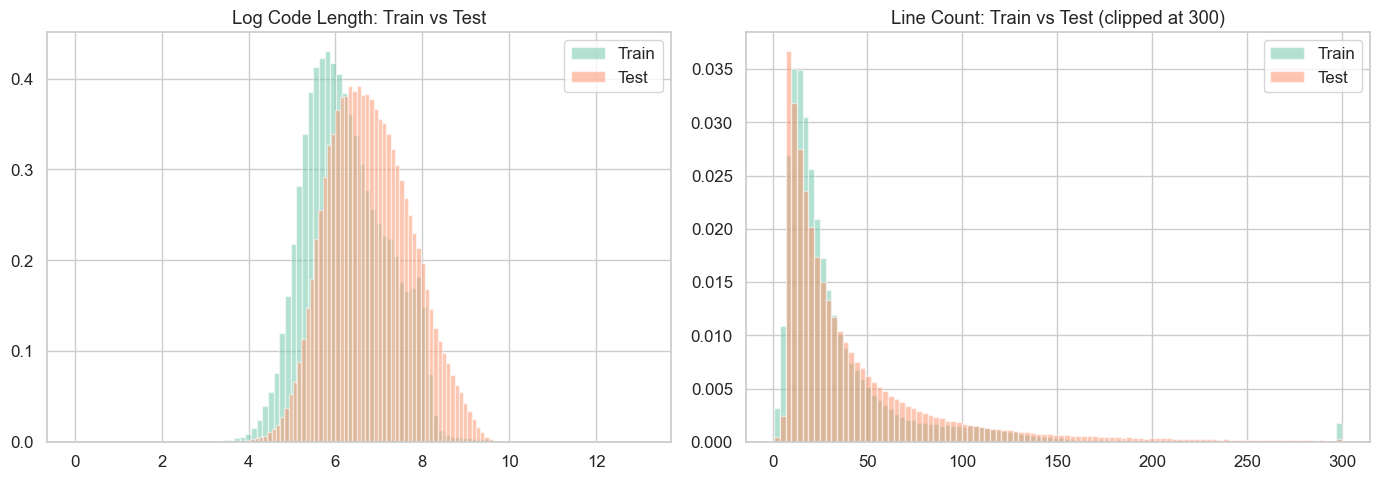

=== Train vs Test Length Stats ===
Train - mean: 837, median: 464, max: 475,006
Test  - mean: 1421, median: 843, max: 54,080


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare length distributions: train vs test
axes[0].hist(np.log1p(train_df['code_length']), bins=100, alpha=0.5, label='Train', density=True)
axes[0].hist(np.log1p(test_df['code_length']), bins=100, alpha=0.5, label='Test', density=True)
axes[0].set_title('Log Code Length: Train vs Test')
axes[0].legend()

axes[1].hist(train_df['num_lines'].clip(upper=300), bins=100, alpha=0.5, label='Train', density=True)
axes[1].hist(test_df['num_lines'].clip(upper=300), bins=100, alpha=0.5, label='Test', density=True)
axes[1].set_title('Line Count: Train vs Test (clipped at 300)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('=== Train vs Test Length Stats ===')
print(f"Train - mean: {train_df['code_length'].mean():.0f}, median: {train_df['code_length'].median():.0f}, max: {train_df['code_length'].max():,}")
print(f"Test  - mean: {test_df['code_length'].mean():.0f}, median: {test_df['code_length'].median():.0f}, max: {test_df['code_length'].max():,}")

## 8.5 Train vs Validation Comparison

Compare distributions between train and validation splits to check for potential data leakage or distribution mismatch.

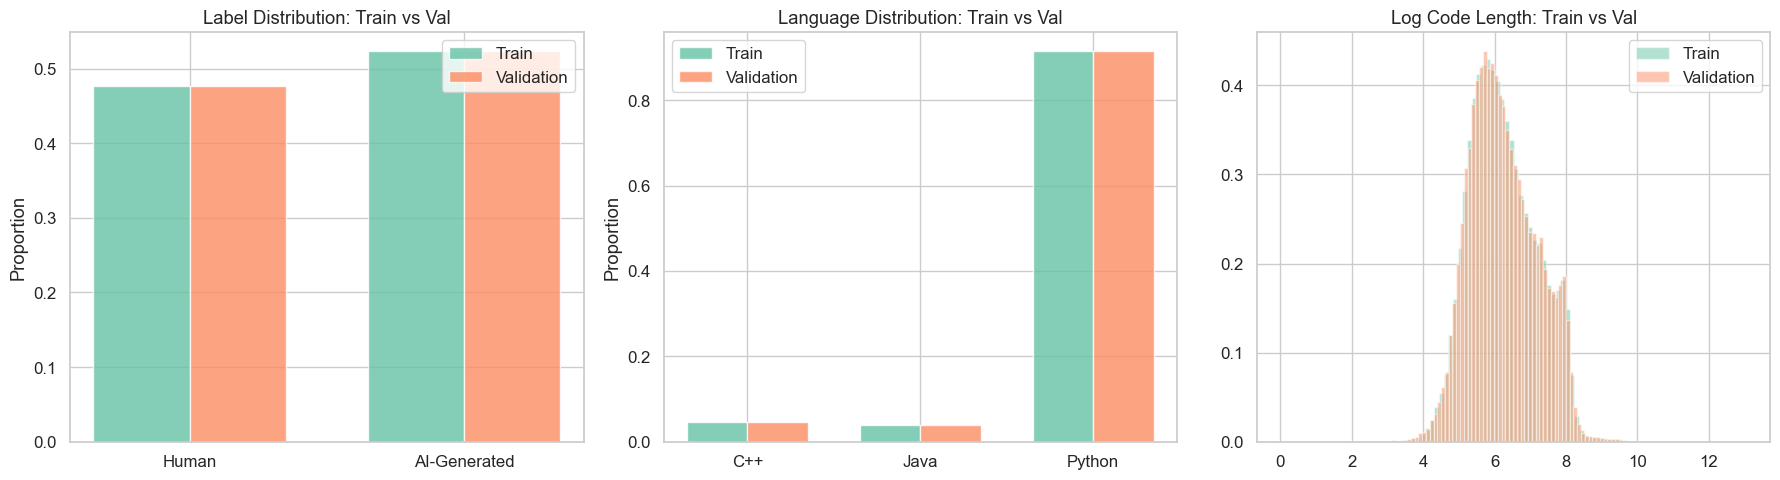

=== Train vs Validation Stats ===
Train - mean: 837, median: 464, std: 1373
Val   - mean: 836, median: 461, std: 1219

Train AI ratio: 0.5231
Val   AI ratio: 0.5231


In [30]:
# Add code_length and num_lines to val_df if not already present
if 'code_length' not in val_df.columns:
    val_df['code_length'] = val_df['code'].str.len()
    val_df['num_lines'] = val_df['code'].str.count('\\n') + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Label distribution comparison
train_label_pct = train_df['label'].value_counts(normalize=True).sort_index()
val_label_pct = val_df['label'].value_counts(normalize=True).sort_index()
x = np.arange(len(train_label_pct))
w = 0.35
axes[0].bar(x - w/2, train_label_pct.values, w, label='Train', alpha=0.8)
axes[0].bar(x + w/2, val_label_pct.values, w, label='Validation', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Human', 'AI-Generated'])
axes[0].set_title('Label Distribution: Train vs Val')
axes[0].set_ylabel('Proportion')
axes[0].legend()

# 2. Language distribution comparison
train_lang_pct = train_df['language'].value_counts(normalize=True).sort_index()
val_lang_pct = val_df['language'].value_counts(normalize=True).sort_index()
x = np.arange(len(train_lang_pct))
axes[1].bar(x - w/2, train_lang_pct.values, w, label='Train', alpha=0.8)
axes[1].bar(x + w/2, val_lang_pct.values, w, label='Validation', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(train_lang_pct.index)
axes[1].set_title('Language Distribution: Train vs Val')
axes[1].set_ylabel('Proportion')
axes[1].legend()

# 3. Code length distribution comparison
axes[2].hist(np.log1p(train_df['code_length']), bins=100, alpha=0.5, label='Train', density=True)
axes[2].hist(np.log1p(val_df['code_length']), bins=100, alpha=0.5, label='Validation', density=True)
axes[2].set_title('Log Code Length: Train vs Val')
axes[2].legend()

plt.tight_layout()
plt.show()

print('=== Train vs Validation Stats ===')
print(f"Train - mean: {train_df['code_length'].mean():.0f}, median: {train_df['code_length'].median():.0f}, std: {train_df['code_length'].std():.0f}")
print(f"Val   - mean: {val_df['code_length'].mean():.0f}, median: {val_df['code_length'].median():.0f}, std: {val_df['code_length'].std():.0f}")
print(f"\nTrain AI ratio: {train_df['label'].mean():.4f}")
print(f"Val   AI ratio: {val_df['label'].mean():.4f}")

In [31]:
# Cross-tabulation: label x language for validation
label_names_inv = {0: 'Human', 1: 'AI-Generated'}

val_ct = pd.crosstab(
    val_df['language'],
    val_df['label'].map(label_names_inv),
    margins=True, margins_name='All'
)

print('=== Validation: Language x Label ===')
display(val_ct)

# Per-language AI ratio comparison
print('\n=== Per-language AI ratio: Train vs Val ===')
for lang in sorted(train_df['language'].unique()):
    train_ratio = train_df[train_df['language'] == lang]['label'].mean()
    val_ratio = val_df[val_df['language'] == lang]['label'].mean()
    print(f'  {lang:8s}: Train={train_ratio:.4f}  Val={val_ratio:.4f}  Δ={abs(train_ratio - val_ratio):.4f}')

=== Validation: Language x Label ===


label,AI-Generated,Human,All
language,,,
C++,2449,2230,4679
Java,2015,1845,3860
Python,47841,43620,91461
All,52305,47695,100000



=== Per-language AI ratio: Train vs Val ===
  C++     : Train=0.5235  Val=0.5234  Δ=0.0001
  Java    : Train=0.5221  Val=0.5220  Δ=0.0000
  Python  : Train=0.5231  Val=0.5231  Δ=0.0000


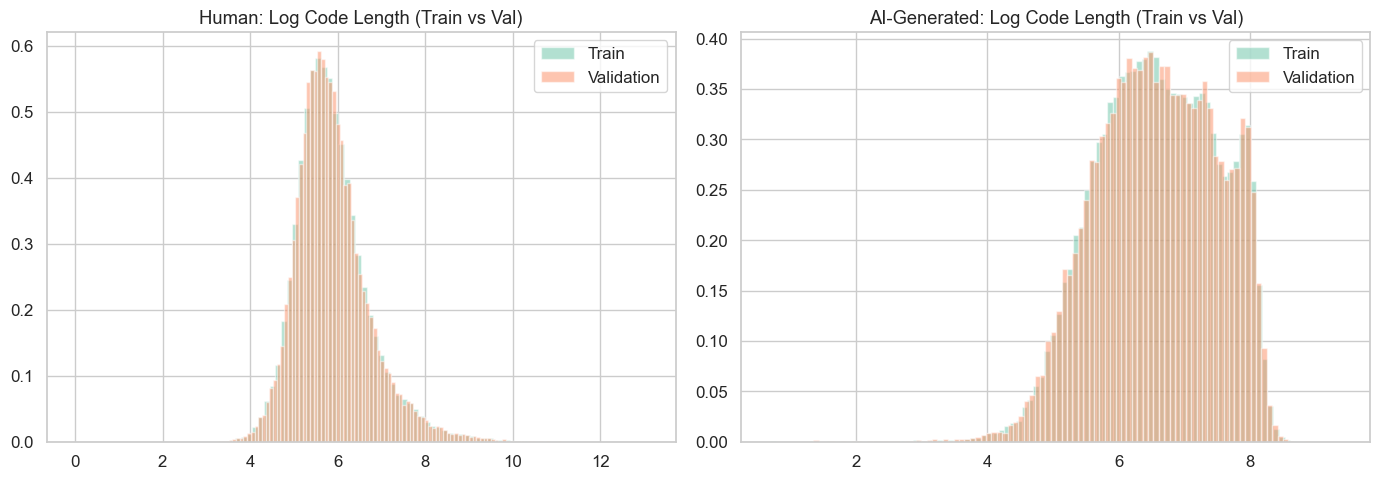

=== Generator overlap ===
Train generators: 35
Val generators:   35
Overlap:          35
All val generators are also in train ✓


In [32]:
# Per-label length distribution: Train vs Validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, label in enumerate([0, 1]):
    label_name = 'Human' if label == 0 else 'AI-Generated'
    train_subset = train_df[train_df['label'] == label]
    val_subset = val_df[val_df['label'] == label]
    
    axes[i].hist(np.log1p(train_subset['code_length']), bins=100, alpha=0.5, label='Train', density=True)
    axes[i].hist(np.log1p(val_subset['code_length']), bins=100, alpha=0.5, label='Validation', density=True)
    axes[i].set_title(f'{label_name}: Log Code Length (Train vs Val)')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Compare generators
print('=== Generator overlap ===')
train_gens = set(train_df['generator'].unique())
val_gens = set(val_df['generator'].unique())
print(f'Train generators: {len(train_gens)}')
print(f'Val generators:   {len(val_gens)}')
print(f'Overlap:          {len(train_gens & val_gens)}')
val_only = val_gens - train_gens
if val_only:
    print(f'Val-only generators (OOD risk): {val_only}')
else:
    print('All val generators are also in train ✓')

## 9. Sample Code Inspection

In [33]:
def show_sample(df, label, language, n=1):
    """Display a code sample."""
    subset = df[(df['label'] == label) & (df['language'] == language)]
    if len(subset) == 0:
        print(f'No samples for label={label}, language={language}')
        return
    sample = subset.sample(n=n, random_state=42).iloc[0]
    label_name = 'Human' if label == 0 else f'AI ({sample["generator"]})'
    print(f'=== {label_name} | {language} | {len(sample["code"]):,} chars ===')
    # Show first 50 lines
    lines = sample['code'].split('\n')[:50]
    print('\n'.join(lines))
    if len(sample['code'].split('\n')) > 50:
        print(f'\n... ({len(sample["code"].split(chr(10)))} total lines)')
    print()

In [34]:
for lang in ['Python', 'C++', 'Java']:
    show_sample(train_df, label=0, language=lang)
    show_sample(train_df, label=1, language=lang)

=== Human | Python | 186 chars ===
z = input()
x = ['4', '7']
c = 0
v = 'NO'
for i in z:
	if i in x:
		c = c + 1
if int(z) % 4 == 0 or int(z) % 7 == 0 or int(z) % 47 == 0:
	v = 'YES'
elif c == len(z):
	v = 'YES'
print(v)


=== AI (meta-llama/Llama-3.3-70B-Instruct) | Python | 433 chars ===
def determine_gender(username: str) -> None:
    """Determine the gender of a user based on their username."""
    distinct_chars = set(username)  # Get distinct characters in the username
    if len(distinct_chars) % 2 == 0:  # Check if the number of distinct characters is even
        print("CHAT WITH HER!")
    else:
        print("IGNORE HIM!")


if __name__ == "__main__":
    username = input()
    determine_gender(username)

=== Human | C++ | 763 chars ===
class Solution {
public:
    int minFlipsMonoIncr(string S) {
        int i, j, len, ans;
        len = S.size();
        vector<int> left(len, 0);
        vector<int> right(len, 0);
        for (i = 0; i < len; i++) {
            if (i > 0) 

## 10. Key Takeaways

Fill in after running the notebook:

- **Label balance:** ...
- **Language imbalance:** Python >> C++ > Java
- **Length differences (human vs AI):** ...
- **Comment density signal:** ...
- **Strongest stylometric signals:** ...
- **Train vs test distribution shift:** ...